<center>
***

# CÓDIGO PYTHON JUPYTER NOTEBOOK: ANÁLISE, TREINO E EXPORTAÇÃO

## PREPARAÇÃO E EXPORTAÇÃO DE MODELO MLP PARA TENSORFLOW (C/C++)

***
</center>

<center>

## ===================
## IMPORTS NECESSÁRIOS
## ===================

</center>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import io
import warnings

# Importações Scikit-learn (Análise Comparativa)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, 
    accuracy_score, 
    f1_score, 
    confusion_matrix
)
from sklearn.svm import SVC, LinearSVC 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier 
from sklearn.neural_network import MLPClassifier

# Importações TensorFlow/Keras (Para o modelo final e exportação TinyML)
import tensorflow as tf
from tensorflow import keras

# Configuração de semente para reprodutibilidade
np.random.seed(42) 
tf.random.set_seed(42)

<center>

## ==================================================
## FUNÇÃO ESSENCIAL: CONVERSÃO TFLITE BINÁRIO PARA ARRAY C (.h)
## ==================================================

</center>

In [2]:
def convert_tflite_to_c_array(tflite_model_content, array_name='g_model', filename='model_data.h'):
    """
    Formata o conteúdo binário do modelo TFLite como um array C (unsigned char)
    e guarda num ficheiro .h.
    """
    hex_list = [f'0x{b:02x}' for b in tflite_model_content]
    c_array_lines = []
    for i in range(0, len(hex_list), 12):
        c_array_lines.append("  " + ", ".join(hex_list[i:i+12]))
        
    c_array_string = ",\n".join(c_array_lines) + ","

    header_content = f"""
#ifndef MODEL_DATA_H
#define MODEL_DATA_H

// Array C/C++ do modelo TFLite otimizado (Gerado automaticamente pelo Python).
const unsigned int {array_name}_len = {len(tflite_model_content)};
const unsigned char {array_name}[] = {{
{c_array_string}
}};

#endif // MODEL_DATA_H
"""
    with open(filename, "w") as f:
        f.write(header_content)
        
    return None

<center>

## ============================================
## PASSO 1: PREPARAÇÃO E DEMONSTRAÇÃO DOS DADOS
## ============================================

</center>

--- STEP 1: DATA PREPARATION ---

[Analysis of Variance of the Total Dataset]
Hue            114.560715
Saturation      27.793886
Value           27.300886
Vibration        2.942351
Metal         1269.886259

INFO: All features have useful variance. No constant columns were found.

Features finais utilizadas: ['Hue', 'Saturation', 'Value', 'Vibration', 'Metal']

Visualizing class balancing...


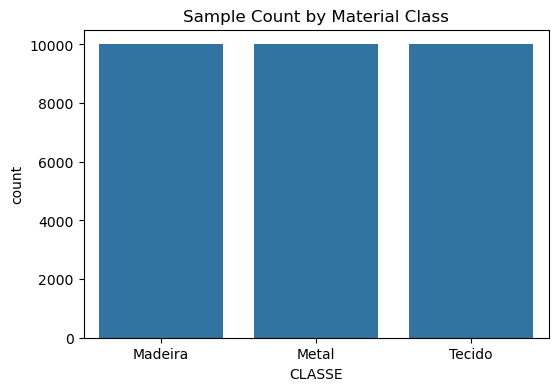


 Data preparation complete. Data scaled.


In [3]:
# Suprime os avisos de RuntimeWarning para limpar o output, pois vamos tratar a causa.
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)


print("--- STEP 1: DATA PREPARATION ---")

# --- 1.1 CONFIGURAÇÃO DE DADOS ---
LISTA_FICHEIROS = ['madeira_dataset.csv', 'metal_dataset.csv', 'tecido_dataset.csv']
MAPA_CLASSES = {'Madeira': 0, 'Metal': 1, 'Tecido': 2}
NUM_CLASSES = len(MAPA_CLASSES)
# ATENÇÃO: As features agora incluem 'Vibration'
FEATURES = ['Hue', 'Saturation', 'Value', 'Vibration', 'Metal'] 


# --- 1.2 CARREGAMENTO E CONCATENAÇÃO ---
try:
    lista_df = [pd.read_csv(f) for f in LISTA_FICHEIROS]
    df_total = pd.concat(lista_df, ignore_index=True)
except FileNotFoundError as e:
    print(f"ERRO CRÍTICO: Ficheiro não encontrado: {e}. O programa não pode continuar.")
    exit() 

df_total['CLASSE_ID'] = df_total['CLASSE'].map(MAPA_CLASSES)
X_features = df_total[FEATURES]
y_alvo = df_total['CLASSE_ID']


# --- 1.3 ANÁLISE CRÍTICA: DESVIO PADRÃO ---
print("\n[Analysis of Variance of the Total Dataset]")

# 1. Calcular o desvio padrão (STD) de cada coluna de feature
std_dev = X_features.std()
print(std_dev.to_string()) # Imprime o STD de todas as colunas!

# 2. Identificar colunas onde o desvio padrão é muito próximo de zero
# Usamos um limite pequeno (1e-6) para apanhar erros de ponto flutuante
LIMITE_ZERO = 1e-6
colunas_constantes = std_dev[std_dev < LIMITE_ZERO].index.tolist()

if colunas_constantes:
    print(f"\nCRITICAL DATA WARNING: The following features are CONSTANT (STD ≈ 0) in all files:")
    print(f" -> {colunas_constantes}")
    print("These columns will be REMOVED to prevent Division by Zero in the StandardScaler.")
    
    # Remove as colunas constantes do nosso conjunto de features
    FEATURES_VALIDAS = [f for f in FEATURES if f not in colunas_constantes]
    X_features = df_total[FEATURES_VALIDAS]
else:
    FEATURES_VALIDAS = FEATURES
    print("\nINFO: All features have useful variance. No constant columns were found.")
    
if not FEATURES_VALIDAS:
    print("CRITICAL ERROR: No valid features remained after the cleanup.")
    exit()

print(f"\nFeatures finais utilizadas: {FEATURES_VALIDAS}")
# -----------------------------------------------------------

# --- 1.4 EXPLORAÇÃO INICIAL (Balanceamento) ---
print("\nVisualizing class balancing...")
plt.figure(figsize=(6, 4))
sns.countplot(x='CLASSE', data=df_total)
plt.title('Sample Count by Material Class')
plt.show()
# 


# --- 1.5 SPLIT E ESCALONAMENTO ---
# Usamos X_features, que agora só contém as colunas válidas
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_features, y_alvo, test_size=0.2, random_state=42, stratify=y_alvo
)

escalador = StandardScaler()
X_treino_escalado = escalador.fit_transform(X_treino)
X_teste_escalado = escalador.transform(X_teste)

print("\n Data preparation complete. Data scaled.")

<center>

## =========================================
## PASSO 2: TREINO E ANÁLISE DETALHADA (SVM)
## =========================================

</center>


--- STEP 2: TRAINING AND COMPARATIVE ANALYSIS SCALING (Scikit-learn) ---

--- FINAL SUMMARY OF PERFORMANCE SCALING (AVERAGES) ---
|              |   Acc_Mean |   F1_Mean |
|:-------------|-----------:|----------:|
| KNN          |     0.9850 |    0.9850 |
| Ext.Forest   |     0.9850 |    0.9850 |
| L.Regression |     0.9850 |    0.9850 |
| Deci.Tree    |     0.9850 |    0.9850 |
| Ran.Forest   |     0.9850 |    0.9850 |
| SVC          |     0.9472 |    0.9464 |
| AdaBoost     |     0.8902 |    0.8892 |
| MLP          |     0.8902 |    0.8892 |
| LinearSVC    |     0.8842 |    0.8825 |


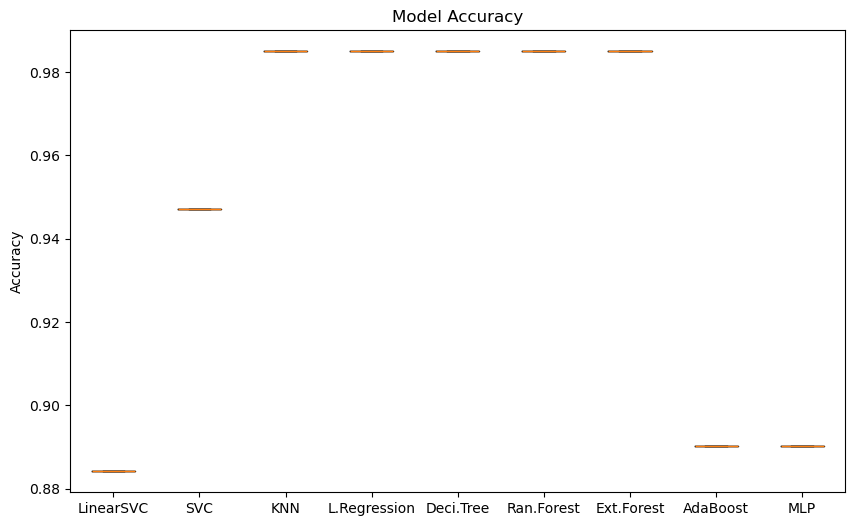

In [4]:
print("\n--- STEP 2: TRAINING AND COMPARATIVE ANALYSIS SCALING (Scikit-learn) ---")

models = [
    "LinearSVC", "SVC", "KNN", "L.Regression", "Deci.Tree", "Ran.Forest", 
    "Ext.Forest", "AdaBoost", "MLP"
]

runs = 5
accuracies = np.zeros((len(models), runs))
f1_weighted = np.zeros((len(models), runs))
melhor_score_sklearn = -1
melhor_nome_sklearn = ""
melhor_modelo_sklearn = None 

# --- LOOP PRINCIPAL DE TREINO ---
for model_to_try_i in range(len(models)):
    model_to_try_name = models[model_to_try_i]

    for try_i in range(runs):
        
        # 1. Instanciar o Modelo
        if model_to_try_name == "LinearSVC":
            model = LinearSVC(C=1.0, max_iter=2000, dual=True, tol=1e-4, random_state=42 + try_i) 
        elif model_to_try_name == "SVC":
            model = SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42 + try_i)
        elif model_to_try_name == "KNN":
            model = KNeighborsClassifier(n_neighbors=5)
        elif model_to_try_name == "LogisticRegression":
            model = LogisticRegression(solver='lbfgs', max_iter=2000, random_state=42 + try_i)
        elif model_to_try_name == "DecisionTree":
            model = DecisionTreeClassifier(max_depth=5, random_state=42 + try_i)
        elif model_to_try_name == "RandomForest":
            model = RandomForestClassifier(n_estimators=100, random_state=42 + try_i)
        elif model_to_try_name == "ExtremeForest":
            model = ExtraTreesClassifier(n_estimators=100, random_state=42 + try_i)
        elif model_to_try_name == "AdaBoost":
            model = AdaBoostClassifier(n_estimators=100, random_state=42 + try_i) 
        elif model_to_try_name == "MLP_sklearn":
            model = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=2000, random_state=42 + try_i)
        
        # 2. Treinar, Testar e Avaliar
        try:
            model.fit(X_treino_escalado, y_treino)
            y_test_predict = model.predict(X_teste_escalado)
            f1_w = f1_score(y_teste, y_test_predict, average='weighted')
            
            accuracies[model_to_try_i, try_i] = accuracy_score(y_teste, y_test_predict)
            f1_weighted[model_to_try_i, try_i] = f1_w
            
            if f1_w > melhor_score_sklearn:
                melhor_score_sklearn = f1_w
                melhor_modelo_sklearn = model
                melhor_nome_sklearn = model_to_try_name

        except Exception:
            accuracies[model_to_try_i, try_i] = 0.0
            f1_weighted[model_to_try_i, try_i] = 0.0


# --- ANÁLISE ESTATÍSTICA E VISUALIZAÇÃO ---
results_df = pd.DataFrame(index=models)
results_df['Acc_Mean'] = accuracies.mean(axis=1)
results_df['F1_Mean'] = f1_weighted.mean(axis=1)
results_df.sort_values(by='F1_Mean', ascending=False, inplace=True)

print("\n--- FINAL SUMMARY OF PERFORMANCE SCALING (AVERAGES) ---")
print(results_df[['Acc_Mean', 'F1_Mean']].to_markdown(floatfmt=".4f"))

# Box Plot da Accuracy
plt.figure(figsize=(10, 6))
plt.boxplot(accuracies.T, tick_labels=[m.split('_')[0] for m in models]) 
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.show()

<center>

## ==========================================
## PASSO 3: MODELO FINAL PARA O ARDUINO (SVM)
## ==========================================

</center>


--- STEP 3: KERAS MODEL TRAINING (MLP) ---
Training for the full 400 epochs.
Epoch 1/400
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9061 - loss: 0.2862 - val_accuracy: 0.9235 - val_loss: 0.1951
Epoch 2/400
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9312 - loss: 0.1761 - val_accuracy: 0.9383 - val_loss: 0.1608
Epoch 3/400
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9392 - loss: 0.1495 - val_accuracy: 0.9405 - val_loss: 0.1427
Epoch 4/400
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9429 - loss: 0.1341 - val_accuracy: 0.9435 - val_loss: 0.1311
Epoch 5/400
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9461 - loss: 0.1230 - val_accuracy: 0.9463 - val_loss: 0.1210
Epoch 6/400
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9492 - loss: 0.1133 - val_accuracy: 0.9507 - val_loss: 0.1119
Epoch 7/400
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9554 - loss: 0.1042 - val_accuracy: 0.9558 - val_loss: 0.1033
Epoch 8/400
750/75

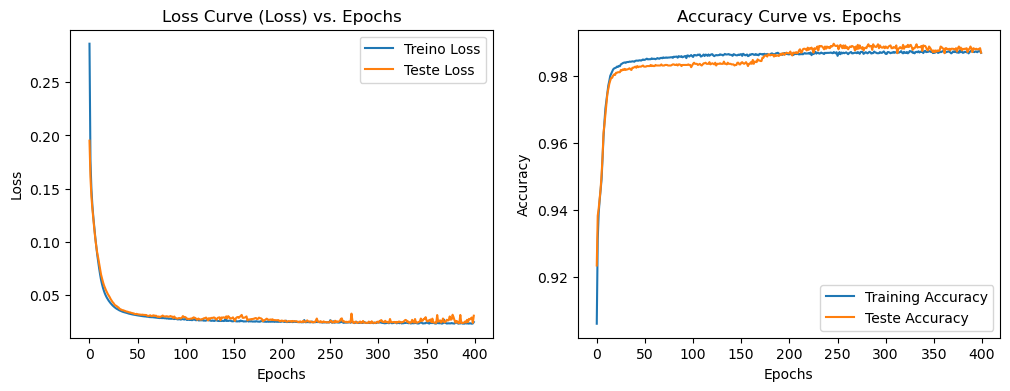

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


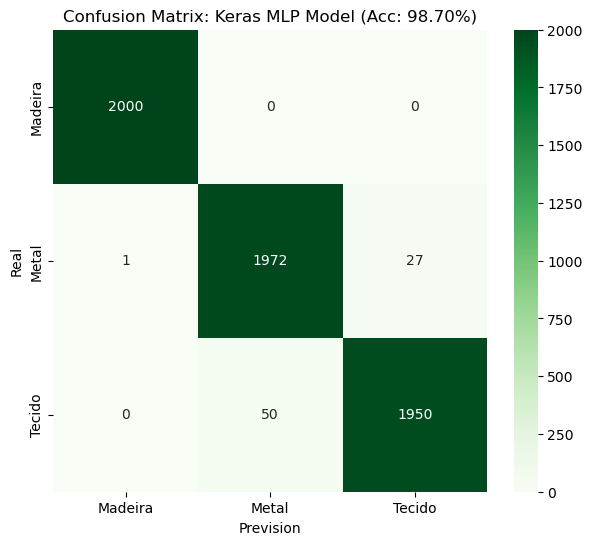

In [5]:
print("\n--- STEP 3: KERAS MODEL TRAINING (MLP) ---")

# --- 3.1 Definir e Compilar Keras ---
# Mantenha a definição do modelo (Sequential, Dense layers) como está
modelo_keras = keras.Sequential([
    # Input Corrigido: Usando keras.layers.Input para remover o UserWarning
    keras.layers.Input(shape=(len(FEATURES_VALIDAS),)), # ATENÇÃO: Use FEATURES_VALIDAS aqui
    # Arquitetura Otimizada: 128 neurónios
    keras.layers.Dense(128, activation='relu'), 
    # Arquitetura Otimizada: 64 neurónios
    keras.layers.Dense(64, activation='relu'),
    # Camada de saída
    keras.layers.Dense(NUM_CLASSES, activation='softmax') 
])

# Otimizador Fino (Learning Rate mais baixa)
otimizador = keras.optimizers.Adam(learning_rate=0.0005) 

modelo_keras.compile(
    optimizer=otimizador,
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

# --- 3.2 Treinar ---

# ANúmero de Epochs
NUM_EPOCHS = 400 

print(f"Training for the full {NUM_EPOCHS} epochs.")
historico = modelo_keras.fit(
    X_treino_escalado, 
    y_treino, 
    epochs=NUM_EPOCHS, 
    verbose=1, # Barra de Progresso
    validation_data=(X_teste_escalado, y_teste),
    # REMOVIDO: callbacks=[early_stopping]
)

# --- 3.3 AVALIAÇÃO E GRÁFICOS ---
loss, acc = modelo_keras.evaluate(X_teste_escalado, y_teste, verbose=0)
print(f"\nTrained Keras Model (MLP). Test Accuracy: {acc*100:.2f}%")

# GRÁFICOS DE CURVA DE TREINO (Loss e Accuracy)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(historico.history['loss'], label='Treino Loss')
plt.plot(historico.history['val_loss'], label='Teste Loss')
plt.title('Loss Curve (Loss) vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(historico.history['accuracy'], label='Training Accuracy')
plt.plot(historico.history['val_accuracy'], label='Teste Accuracy')
plt.title('Accuracy Curve vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


# Matriz de Confusão do Keras
y_previsoes_keras = np.argmax(modelo_keras.predict(X_teste_escalado), axis=1)
nomes_classes = list(MAPA_CLASSES.keys())
cm_keras = confusion_matrix(y_teste, y_previsoes_keras)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_keras, annot=True, fmt='d', cmap='Greens', 
    xticklabels=nomes_classes, yticklabels=nomes_classes
)
plt.title(f'Confusion Matrix: Keras MLP Model (Acc: {acc*100:.2f}%)')
plt.xlabel('Prevision')
plt.ylabel('Real')
plt.show()

<center>

## ===========================
## PASSO 4: EXPORTAÇÃO PARA .h
## ===========================

</center>

In [7]:
print("\n--- STEP 4: EXPORTING TINYML TO C/C++ (.h FILES) ---")

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
tf.get_logger().setLevel(logging.ERROR)

if not os.path.exists("tflite_exports"): os.makedirs("tflite_exports")
    
# --- 4.1 Criar Ficheiro do Scaler (scaler_parameters.h) ---
mean_arr = escalador.mean_.tolist()
scale_arr = escalador.scale_.tolist()
scaler_code = f"""
#ifndef SCALER_PARAMETERS_H
#define SCALER_PARAMETERS_H

// Parâmetros do Standard Scaler (Média e Desvio Padrão)
const int NUM_FEATURES = {len(FEATURES)};
const float SCALER_MEAN[NUM_FEATURES] = {mean_arr};
const float SCALER_STD[NUM_FEATURES] = {scale_arr};

#endif // SCALER_PARAMETERS_H
"""
scaler_header_path = "tflite_exports/scaler_parameters.h"
with open(scaler_header_path, "w") as f:
    f.write(scaler_code)


# --- 4.2 Converter Keras para TFLite Binário ---
converter = tf.lite.TFLiteConverter.from_keras_model(modelo_keras)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16] 

tflite_model = converter.convert()

# --- 4.3 Conversão Automática para Array C (.h) ---
model_header_path = "tflite_exports/model_data.h"

# O print foi removido aqui:
convert_tflite_to_c_array(
    tflite_model, 
    array_name='g_model',
    filename=model_header_path
)

# --- EXIBE A MENSAGEM FINAL ---
print(f"\n EXPORTATION SUCCESSFULLY COMPLETED!")
print("Copy BOTH .h FILES :")
print(f"- '{scaler_header_path}'")
print(f"- '{model_header_path}'")


--- STEP 4: EXPORTING TINYML TO C/C++ (.h FILES) ---
Saved artifact at 'C:\Users\pedro\AppData\Local\Temp\tmp6qe7yeg3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 5), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2668315951696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2668316083824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2668316094032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2668316091744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2668316095616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2668316096144: TensorSpec(shape=(), dtype=tf.resource, name=None)

 EXPORTATION SUCCESSFULLY COMPLETED!
Copy BOTH .h FILES :
- 'tflite_exports/scaler_parameters.h'
- 'tflite_exports/model_data.h'
